#  Le challenge "Puzzle"

**Dans cette partie, nous réalisons une expérience comparative démontrant la différence de biais inductif entre un CNN et un Visual Transformer (ViT). 
Nous allons entraîner ces deux architectures sur deux versions du jeu de données Imagenette, l'une avec des images intactes et l'autre avec des images "puzzlées" (divisées en patches mélangés aléatoirement).
Le but est d'observer comment chaque architecture gère la perte de structure spatiale dans les images.
On devrait constater que le CNN, qui s'appuie fortement sur les relations spatiales locales, voit ses performances chuter significativement sur les images puzzlées.
En revanche, le ViT, grâce à son mécanisme d'attention globale, devrait être plus robuste à cette perturbation.**


## Image "puzzlée" ?

Transformation qui divise l'image en patches 14x14, puis mélange ces patches selon une permutation aléatoire.

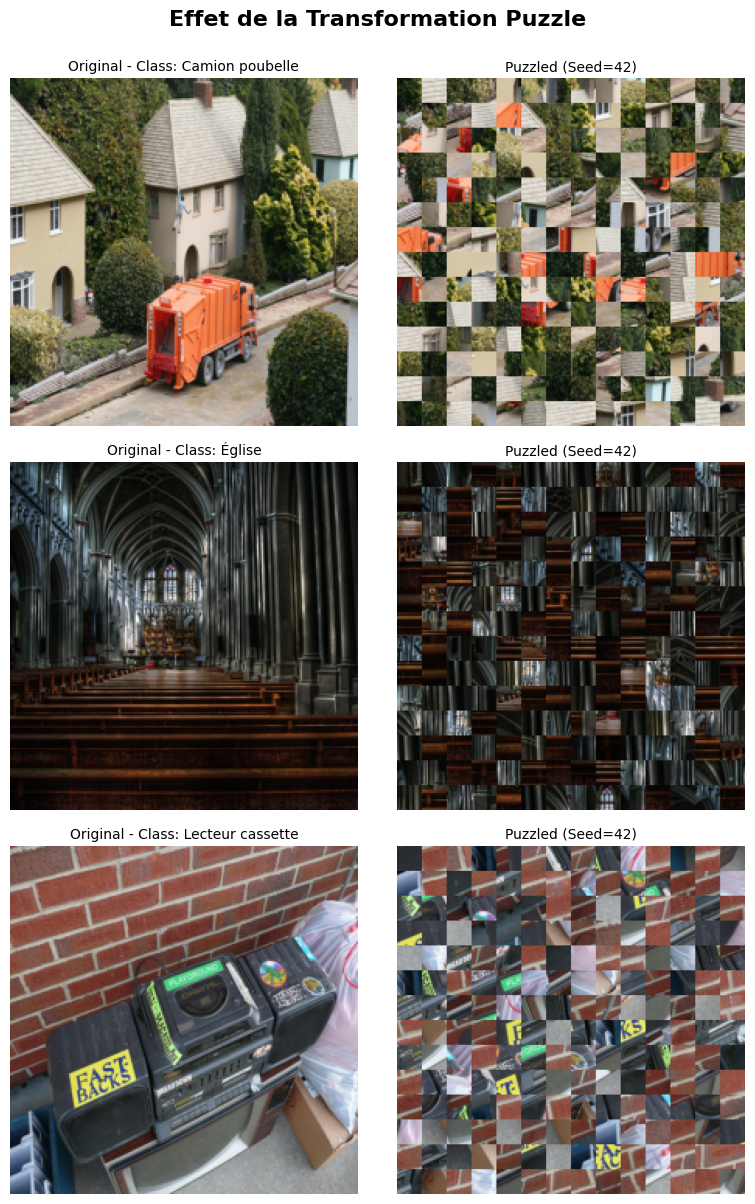

In [2]:
from puzzle_experiment import PuzzlePermutation
from visualisations import visualize_puzzle_effect
from dataloader import create_dataloaders

_, val_loader, _ = create_dataloaders(use_puzzle=False)
puzzle_transform = PuzzlePermutation(seed=42)

visualize_puzzle_effect(puzzle_transform, val_loader.dataset, num_samples=3)

## Expériences réalisées

Nous avons entraîné **4 modèles** sur Imagenette (un sous-ensemble d'ImageNet composé de 10 classes simples), sur 10 epochs, fine-tuning la tête de classification avec backbone gelé, pour les ViT, le fine-tune a aussi été fait sur le positional embedding :

1. **ResNet-50** sur images **originales**
2. **ResNet-50** sur images **puzzlées**  
3. **ViT-Base/16** sur images **originales**
4. **ViT-Base/16** sur images **puzzlées**

Nous allons maintenant voir les résultats obtenus ainsi que les courbes de loss et accuracy.

In [7]:
# Chargement des résultats d'entraînement
import json
import matplotlib.pyplot as plt
import numpy as np

# Charger les 4 expériences
histories = {}
file_names = {
    'ResNet_Original': 'history_ResNet_Original.json',
    'ViT_Original': 'history_ViT_Original.json', 
    'ResNet_Puzzle': 'history_ResNet_Puzzle.json',
    'ViT_Puzzle': 'history_ViT_Puzzle.json'
}

for model_name, file_name in file_names.items():
        with open(f'results/{file_name}', 'r') as f:
            histories[model_name] = json.load(f)

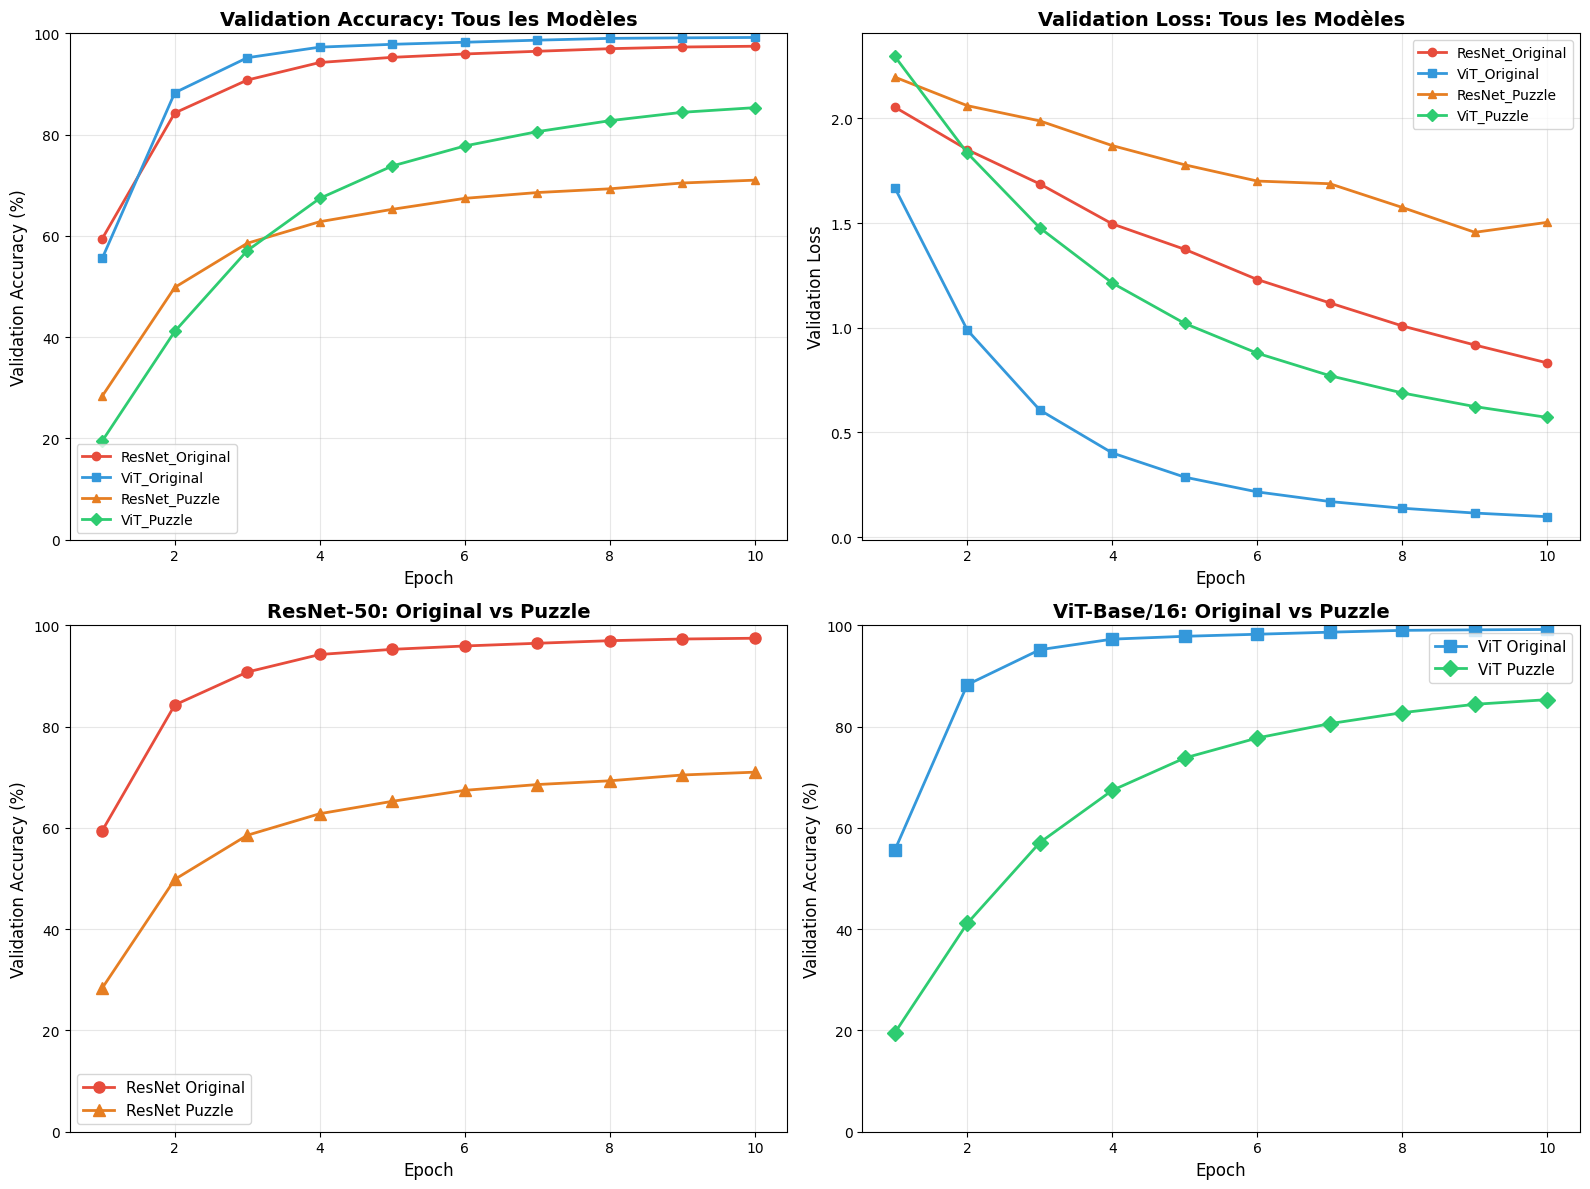

In [8]:
# Graphique de comparaison complet
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs = range(1, 11)  # 10 epochs

# Couleurs pour chaque modèle
colors = {
    'ResNet_Original': '#e74c3c',
    'ViT_Original': '#3498db',
    'ResNet_Puzzle': '#e67e22', 
    'ViT_Puzzle': '#2ecc71'
}

markers = {
    'ResNet_Original': 'o',
    'ViT_Original': 's',
    'ResNet_Puzzle': '^',
    'ViT_Puzzle': 'D'
}

# 1. Validation Accuracy - Tous les modèles
for model_name, history in histories.items():
    axes[0, 0].plot(epochs, history['val_acc'],
                   marker=markers[model_name], linestyle='-',
                   color=colors[model_name], label=model_name,
                   linewidth=2, markersize=6)

axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[0, 0].set_title('Validation Accuracy: Tous les Modèles', 
                     fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(0, 100)

# 2. Validation Loss - Tous les modèles
for model_name, history in histories.items():
    axes[0, 1].plot(epochs, history['val_loss'],
                   marker=markers[model_name], linestyle='-',
                   color=colors[model_name], label=model_name,
                   linewidth=2, markersize=6)

axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Validation Loss', fontsize=12)
axes[0, 1].set_title('Validation Loss: Tous les Modèles',
                     fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. ResNet: Original vs Puzzle
axes[1, 0].plot(epochs, histories['ResNet_Original']['val_acc'],
               'o-', label='ResNet Original', linewidth=2, markersize=8,
               color=colors['ResNet_Original'])
axes[1, 0].plot(epochs, histories['ResNet_Puzzle']['val_acc'],
               '^-', label='ResNet Puzzle', linewidth=2, markersize=8,
               color=colors['ResNet_Puzzle'])

axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1, 0].set_title('ResNet-50: Original vs Puzzle',
                     fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(0, 100)

# 4. ViT: Original vs Puzzle
axes[1, 1].plot(epochs, histories['ViT_Original']['val_acc'],
               's-', label='ViT Original', linewidth=2, markersize=8,
               color=colors['ViT_Original'])
axes[1, 1].plot(epochs, histories['ViT_Puzzle']['val_acc'],
               'D-', label='ViT Puzzle', linewidth=2, markersize=8,
               color=colors['ViT_Puzzle'])

axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Validation Accuracy (%)', fontsize=12)
axes[1, 1].set_title('ViT-Base/16: Original vs Puzzle',
                     fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

**Comme on peut le voir sur les graphes de loss et d'accuracy, les deux réseaux excellent sur les images originales, atteignant une accuracy quasi-parfaite après 10 epochs. Cependant, lorsque les images sont puzzlées, le ResNet-50 subit une chute de performance et tombe à environ 70% soit un perte de plus de 25% d'accuracy. En revanche, le ViT-Base/16 montre une bien meilleure robustesse, passant de 99% à environ 83% après 10 epochs (plus d'epochs auraient probablement permis d'améliorer encore cette performance comme on voit que la loss continue de diminuer).**

**En conclusion, cette expérience illustre clairement le biais inductif des CNNs, qui dépendent fortement de la structure spatiale locale des images. Le ViT, avec son attention globale, est moins affecté par la perturbation introduite par le puzzlage des images, démontrant ainsi sa capacité à capturer des relations plus globales dans les données visuelles.**